Last edited: 1/28/2026, 3:38 PM CST
# Bias vs. Variance Explained Analysis for Nonstationary GEV Fits to CMIP6 Models
## All mems + primary mems

In [ ]:
# import base packages for data analysis
import numpy as np
import matplotlib.pyplot as plt

from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.bias_vs_corr import (plot_bias_vs_corr, compute_primary_member_bias_vs_corr,
                                                  print_summary)

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

SAVE_FIGS = True

## Step 0: Set Data Attributes for Analysis

In [2]:
trend_vars = ['loc_t', 'scale_t', 'shape_t']

In [3]:
# shared attributes
primary_fit = 'stat_gumbel'  # from mle_attrs.yaml
secondary_fit = 'nonstat_gumbel_only_loc_trend'  # from mle_attrs.yaml
anom_type = 'annmean'  # raw, trend, or annmean
ex_type = 'max'  # max or min

# set anomaly type
data_type = 'raw' if anom_type == 'raw' else f"anom_{anom_type}"

In [4]:
# attributes of ERA5 data
TMIN = 1979  # 1979 or 1950
era5_variable = f't2m_annual_{ex_type}'
GRID = '1deg'

In [5]:
# attributes of CMIP data
cmip_variable = f'tas_annual_{ex_type}'
mip = 'amip'  # amip or cmip

In [6]:
primary_fit_output = compute_primary_member_bias_vs_corr(primary_fit,
                                                         anom_type,
                                                         ex_type,
                                                         data_type,
                                                         TMIN,
                                                         GRID,
                                                         mip)

secondary_fit_output = compute_primary_member_bias_vs_corr(secondary_fit,
                                                           anom_type,
                                                           ex_type,
                                                           data_type,
                                                           TMIN,
                                                           GRID,
                                                           mip)

primary_vars = ['loc', 'scale']
secondary_vars = ['loc_t']

final_output = {}
for var_key in ['med_abs_dev_prim', 'med_abs_dev_most', 'mean_abs_dev_prim', 'mean_abs_dev_most', 'r2s_prim', 'r2s_most']:
    merged = {}
    merged.update({k: primary_fit_output[var_key][k] for k in primary_vars})
    merged.update({k: secondary_fit_output[var_key][k] for k in secondary_vars})
    final_output[var_key] = merged


Warning [loc]: x-axis limits [-0.938, 2.342] clips models: KACE-1-0-G, MPI-ESM-1-2-HAM
Warning [scale]: x-axis limits [-0.276, 0.031] clips models: GFDL-ESM4
Warning [loc_t]: x-axis limits [-0.030, 0.091] clips models: CanESM5, MPI-ESM-1-2-HAM


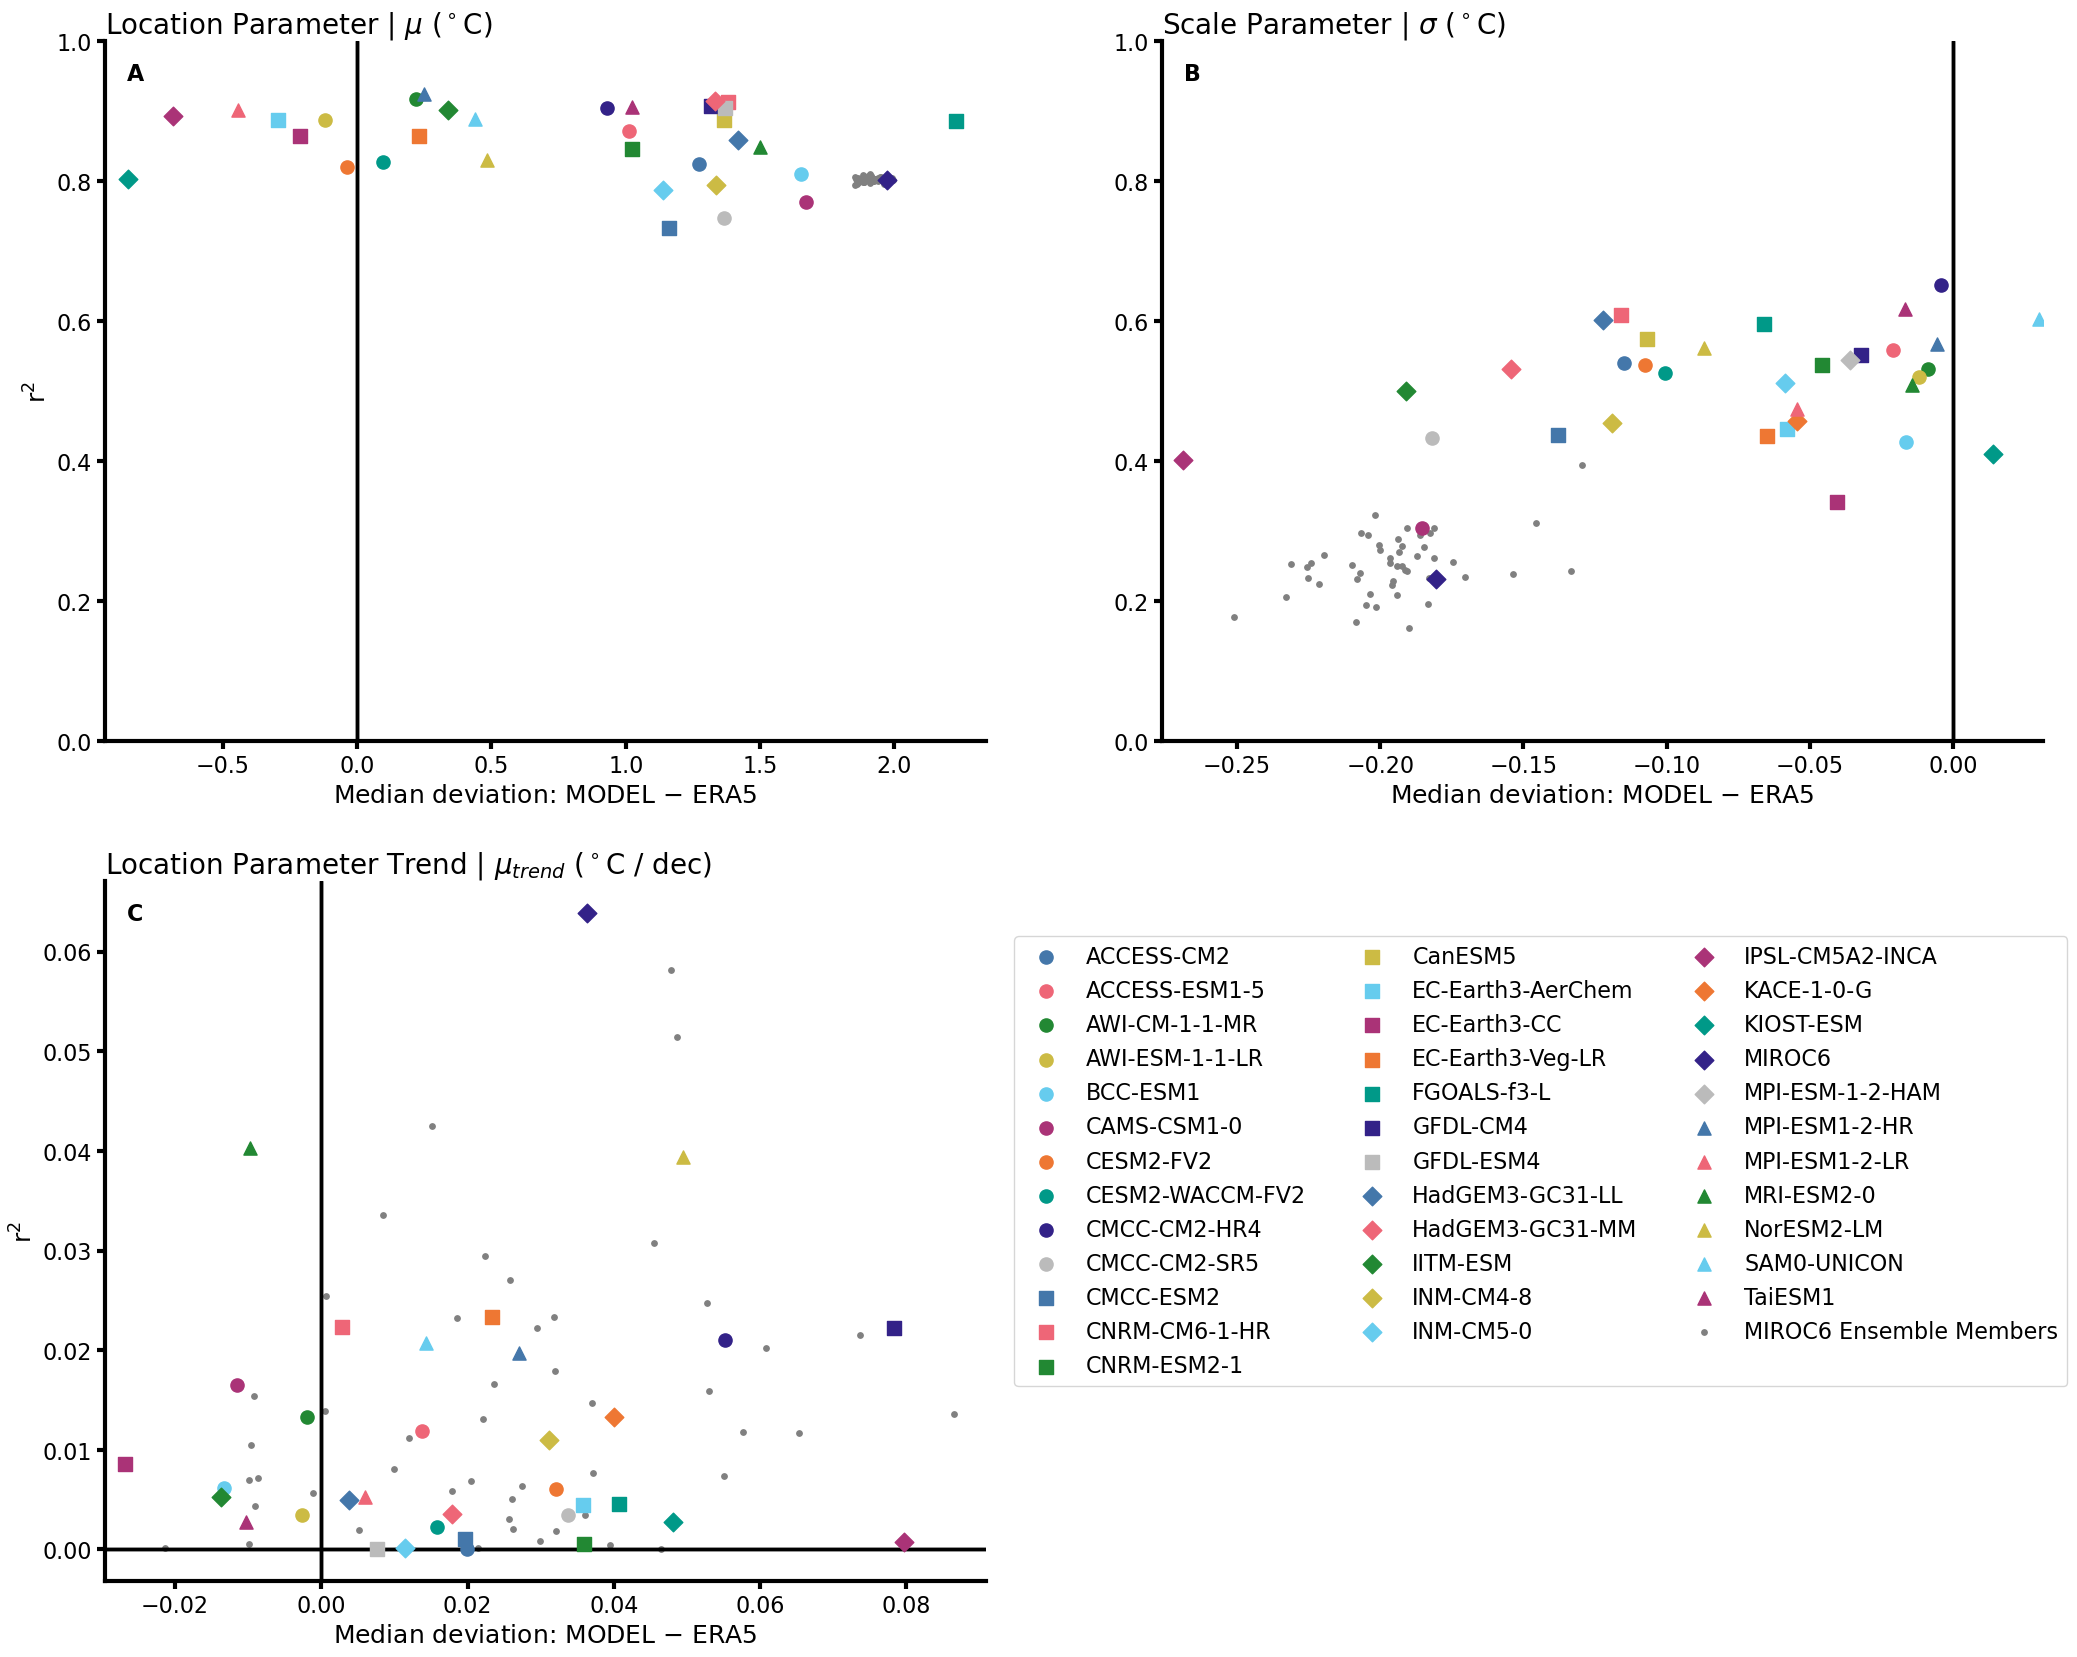

In [7]:
plot_bias_vs_corr(
    abs_dev_prim=final_output['med_abs_dev_prim'], r2s_prim=final_output['r2s_prim'],
    abs_dev_most=final_output['med_abs_dev_most'], r2s_most=final_output['r2s_most'],
    param_order=['loc', 'scale', 'loc_t'], N_params=3,
    models=list(primary_fit_output['cmip_config'].iter_active_models(cmip_variable)),
    model_with_most=primary_fit_output['model_with_most'], med_or_mean='med',
    fname=f'all_cmip_era5_r2_medbias_{cmip_variable}_{anom_type}_{primary_fit}_{secondary_fit}_hybrid',
    save_figs=False
)

In [8]:
print_summary(final_output['r2s_prim'], final_output['r2s_most'], primary_fit_output['cmip_config'], 
              f'tas_annual_{ex_type}', primary_fit_output['model_with_most'], 50,
              fit=(secondary_fit if secondary_fit is not None else primary_fit))

SUMMARY STATISTICS
--------------------------------------------------------------------------------
Parameter: loc
    Primary members only - mean R^2: 0.857, median R^2: 0.866, max R^2: 0.924
    Primary + all members - mean R^2: 0.825, median R^2: 0.804, max R^2: 0.924

Parameter: loc_t
    Primary members only - mean R^2: 0.012, median R^2: 0.006, max R^2: 0.064
    Primary + all members - mean R^2: 0.014, median R^2: 0.008, max R^2: 0.064

Parameter: scale
    Primary members only - mean R^2: 0.503, median R^2: 0.528, max R^2: 0.652
    Primary + all members - mean R^2: 0.357, median R^2: 0.294, max R^2: 0.652

